# code to create recall correlation matrices (Figure _?_)

### imports

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
from itertools import zip_longest
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl
import seaborn as sns

% matplotlib inline

### set paths

In [3]:
data_dir = '../../data'
ep_traj_dir = f'{data_dir}/models/episodes/trajectories'
ep_eventseg_dir = f'{data_dir}/models/episodes/eventseg-models'
rec_traj_dir = f'{data_dir}/models/recalls/trajectories'
rec_eventseg_dir = f'{data_dir}/models/recalls/eventseg-models'
pickle_dir = f'{data_dir}/pickles'

### load data

In [4]:
# recall trajectories
recall_trajectories = {rectype : [] for rectype in ['atlep1', 'atlep2', 'arrdev', 'delayed', 'prediction']}

for rectype in recall_trajectories.keys():
    rt_dir = os.path.join(rec_traj_dir, rectype)
    for file in [f for f in os.listdir(rt_dir) if f.startswith('debug')]:
        recall_trajectories[rectype].append((os.path.splitext(file)[0], np.load(os.path.join(rt_dir, file))))
    
# recall eventseg models
recall_eventsegs = {k : {} for k in recall_trajectories.keys()}
for rectype in recall_eventsegs.keys():
    rt_dir = os.path.join(rec_eventseg_dir, rectype)
    for file in [f for f in os.listdir(rt_dir) if f.startswith('debug')]:
        fpath = os.path.join(rt_dir, file)
        with open(fpath, 'rb') as f:
            recall_eventsegs[rectype][os.path.splitext(file)[0]] = pickle.load(f)
        
# across-session ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

### functioins

In [18]:
def draw_bounds(ax, eventseg_model):
    """
    Draw event boundaries on a temporal correlation matrix heatmap 
    based on based on a fit brainiak.eventseg.event.EventSegment model
    """
    segments = eventseg_model.segments_[0]   
    bounds = np.where(np.diff(np.argmax(segments, axis=1)))[0]
    bounds_aug = np.concatenate(([0],bounds,[segments.shape[0]]))
    for i in range(len(bounds_aug)-1):
        rect = patches.Rectangle((bounds_aug[i], bounds_aug[i]), bounds_aug[i+1]-bounds_aug[i], 
                                 bounds_aug[i+1]-bounds_aug[i], linewidth=1.5, edgecolor='#FFF9AE', 
                                 facecolor='none')
        ax.add_patch(rect)
    return ax

## make order of participants consistent across plots

## plot recall temporal correlation matrices

In [6]:
# plot params
cmap = plt.cm.bone_r
sns.set_context('talk')

# create folder for corrmats
corrmats_dir = '../../paper/figures/corrmats'
if not os.path.isdir(corrmats_dir):
    os.mkdir(corrmats_dir)

58
59
60
61
62
63


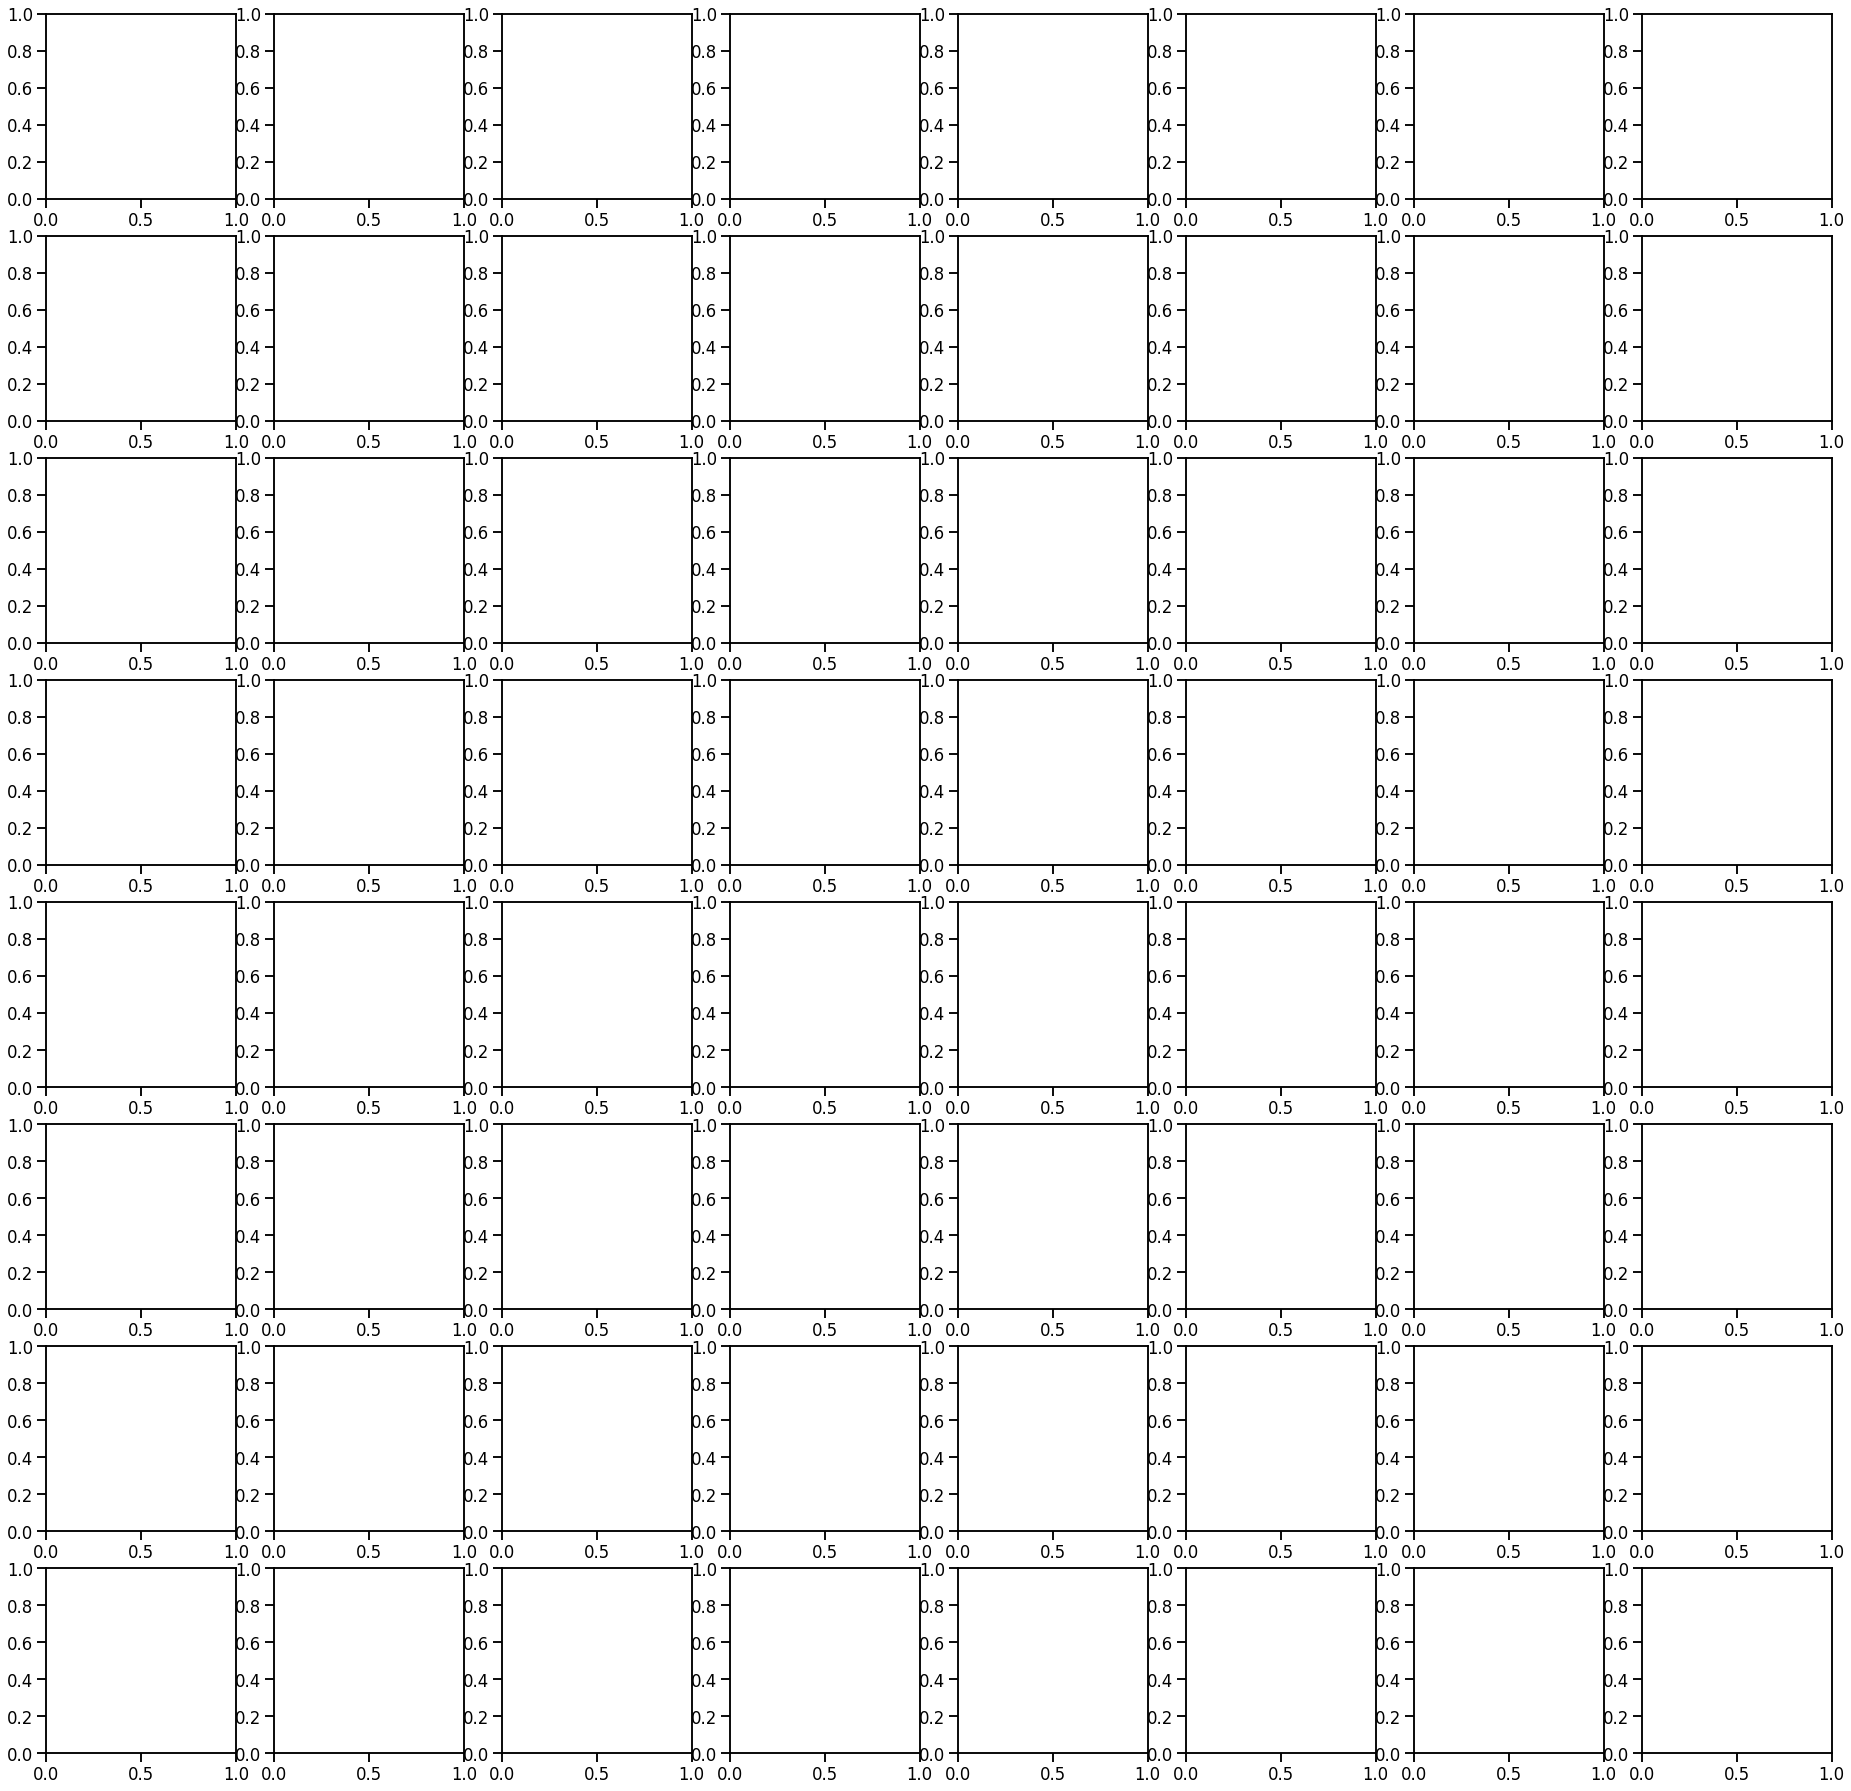

In [12]:
for rectype, r_trajs in recall_trajectories.items():
    fig, axes = plt.subplots(len(r_trajs)//8 + 1, 8)
    fig.set_size_inches(len(axes[0])*4,len(axes)*4)
    axes = axes.flatten()
        
    for i, (ax, r_traj) in enumerate(zip_longest(axes, r_trajs)):
        if not r_traj:
            ax.axis('off')
            continue
        
        turkid, traj = r_traj
        if rectype == 'prediction':
            rt = rectype.capitalize()
        else:
            rt = 'Recall'
            
        data = pd.DataFrame(traj).T.corr()
        ax = sns.heatmap(data, cmap=cmap, xticklabels=500, yticklabels=500, vmin=0, vmax=1, cbar=False, ax=ax)
        ax.set_xlabel(f'{rt} timepoint (s)')
        ax.set_ylabel(f'{rt} timepoint (s)')
        ax.set_title(f'P{i+1}')
        

In [16]:
for sid, mapping in id_maps.items():
    print(mapping)
    break

{'session 1': 'debugIEH2T:debugDLVLJ', 'session 2': 'debug2Ea7T:debugosNZ7'}


In [17]:
mapping['session 1']

'debugIEH2T:debugDLVLJ'

In [18]:
from collections import OrderedDict

In [19]:
test = OrderedDict(id_maps)

In [23]:
test['MD-101218-A-01']

{'session 1': 'debugIEH2T:debugDLVLJ', 'session 2': 'debug2Ea7T:debugosNZ7'}

In [29]:
pd.DataFrame(id_maps).T

,session 1,session 2
MD-101218-A-01,debugIEH2T:debugDLVLJ,debug2Ea7T:debugosNZ7
MD-101218-B-01,debugBUnNA:debugLtZcs,debugQEynG:debugpwxCU
MD-101218-A-02,debugYQfMB:debugxg7il,debugyBEnU:debugSXeyx
MD-101218-B-02,debugd1YD1:debug4FrAg,debugbu5Bq:debugl91xD
MD-101218-A-03,debug92cgv:debugvdAIT,debugIFCgX:debugt0bgV
MD-101218-B-03,debugGaDml:debugFTHoY,debugBB0yq:debug30NBt
MD-101218-A-04,debugmFRWe:debug4RZkW,debugBhGxH:debugMWNLW
MD-101318-B-01,debug3dOrm:debugAjPUS,debugdHg9G:debugnb698
MD-101318-B-02,debugdhnfF:debug6fW93,debugS5d5Q:debugpxU3l
MD-101318-A-02,debugvnS2Q:debugG20gK,debugNTcAd:debugiaabY


In [30]:
with open(f'{pickle_dir}/expdf.p', 'rb') as f:
    expdf = pickle.load(f)

In [36]:
expdf

,uniqueid,datastring,beginhit,endhit,hitid,status,testroom,preqtime,Subject ID,"Outside of this study, have you ever watched an episode of either of the TV shows ""Atlanta"" or ""Arrested Development?""",...,What is/was your major?,How many hours of sleep did you get last night?,How many cups of coffee have you had today?,How alert are you feeling?,postqtime,How engaging did you find the episode?,How easy/difficult was it to follow the episode?,How well do you feel you recalled the events of the episode?,How well do you feel you learned the characters' names over the course of the episode?,How tired do you feel?
0,debugIEH2T:debugDLVLJ,"{'condition': 0, 'counterbalance': 0, 'assignm...",2018-10-12 18:14:31.394716,2018-10-12 19:12:06.999050,debug7rmxU,3.0,1.0,1539368143000,MD-101218-A-01,I've never watched either one,...,undeclared,7,1,A little alert,1539371520000,Very engaging,Somewhat easy,Very well,Very well,A little tired
1,debugBUnNA:debugLtZcs,"{'condition': 0, 'counterbalance': 0, 'assignm...",2018-10-12 19:17:03.503575,2018-10-12 20:10:44.883411,debugTkKFp,3.0,1.0,1539371933000,MD-101218-B-01,I've never watched either one,...,undeclared,5,0,A little sluggish,1539374995000,A little engaging,Somewhat easy,Very well,Somewhat well,A little tired
2,debugYQfMB:debugxg7il,"{'condition': 0, 'counterbalance': 0, 'assignm...",2018-10-12 19:27:41.895057,2018-10-12 20:19:45.738723,debugnwalU,3.0,2.0,1539372538000,MD-101218-A-02,I've never watched either one,...,undeclared,7,2,A little alert,1539375570000,Very engaging,Somewhat easy,Somewhat well,Somewhat well,A little tired
3,debugd1YD1:debug4FrAg,"{'condition': 0, 'counterbalance': 0, 'assignm...",2018-10-12 20:22:07.319435,2018-10-12 21:09:46.566325,debugonOYk,3.0,1.0,1539375802000,MD-101218-B-02,I've never watched either one,...,neuroscience,9,0,A little alert,1539378568000,Very engaging,Very easy,Very well,Somewhat well,A little alert
4,debug92cgv:debugvdAIT,"{'condition': 0, 'counterbalance': 0, 'assignm...",2018-10-12 20:30:14.351756,2018-10-12 21:19:34.104523,debugxHkRX,3.0,2.0,1539376286000,MD-101218-A-03,I've never watched either one,...,Sociology,7,0,A little alert,1539379114000,Very engaging,Somewhat easy,Very well,Somewhat well,Very alert
5,debugGaDml:debugFTHoY,"{'condition': 0, 'counterbalance': 0, 'assignm...",2018-10-12 21:28:01.305584,2018-10-12 22:16:31.057617,debugXHY6O,3.0,1.0,1539379748000,MD-101218-B-03,I've never watched either one,...,undeclared,8,0,A little alert,1539382561000,A little engaging,Somewhat easy,Neutral,Neutral,Neutral
6,debugmFRWe:debug4RZkW,"{'condition': 0, 'counterbalance': 0, 'assignm...",2018-10-12 21:30:34.220872,2018-10-12 22:23:10.006172,debugfYl0n,3.0,2.0,1539379944000,MD-101218-A-04,I've never watched either one,...,Undeclared (but planning on being a psychology...,8,1,Very sluggish,1539382935000,Very engaging,Neutral,Somewhat well,Not very well,A little tired
7,debug3dOrm:debugAjPUS,"{'condition': 0, 'counterbalance': 0, 'assignm...",2018-10-13 18:33:46.272794,2018-10-13 19:31:06.315471,debugRcsF5,3.0,2.0,1539455701000,MD-101318-B-01,I've never watched either one,...,Undeclared,7,2,Neutral,1539459059000,Very engaging,Somewhat easy,Somewhat well,Somewhat well,Very alert
8,debugdhnfF:debug6fW93,"{'condition': 0, 'counterbalance': 0, 'assignm...",2018-10-13 19:35:43.889748,2018-10-13 20:32:37.663906,debugszpCm,3.0,1.0,1539459418000,MD-101318-B-02,I've never watched either one,...,Psychology,6,1,Neutral,1539462754000,Very engaging,Somewhat easy,Somewhat well,Not very well,A little tired
9,debugvnS2Q:debugG20gK,"{'condition': 0, 'counterbalance': 0, 'assignm...",2018-10-13 19:37:50.513846,2018-10-13 20:24:14.393665,debug8qM6C,3.0,2.0,1539459569000,MD-101318-A-02,I've never watched either one,...,Biology,7,0,Neutral,1539462249000,Very engaging,Somewhat easy,Somewhat well,Somewhat well,A little tired


In [38]:
with open(f'{pickle_dir}/expdf.p', 'wb') as f:
    pickle.dump(expdf, f)

In [45]:
id_maps = pd.DataFrame(index=expdf['Subject ID'].unique(), columns=['session 1', 'session 2'])

In [50]:
if pd.isnull(id_maps.loc['MD-101218-A-01', 'session 1']):
    print('a')

In [47]:
id_maps.loc['MD-101218-A-01', 'session 1']

nan

In [44]:
expdf['Subject ID'].unique()

array(['MD-101218-A-01', 'MD-101218-B-01', 'MD-101218-A-02',
       'MD-101218-B-02', 'MD-101218-A-03', 'MD-101218-B-03',
       'MD-101218-A-04', 'MD-101318-B-01', 'MD-101318-B-02',
       'MD-101318-A-02', 'MD-101318-A-03', 'MD-101318-B-03',
       'MD-101318-A-04', 'MD-101318-B-04', 'MD-101318-B-05',
       'MD-101318-A-06', 'MD-101318-B-06', 'MD-101618-A-01',
       'MD-101618-B-01', 'MD-101618-A-02', 'MD-101618-B-02',
       'MD-101618-A-03', 'MD-101618-B-03', 'MD-101618-A-04',
       'MD-101618-B-04', 'MD-102018-A-01', 'MD-102018-B-01',
       'MD-102018-A-02', 'MD-102018-B-02', 'MD-102018-A-03',
       'MD-102118-A-01', 'MD-102218-B-01', 'MD-102218-A-01',
       'MD-102218-B-02', 'MD-102218-A-02', 'MD-102218-B-03',
       'MD-102218-B-05', 'MD-102218-A-05', 'MD-102218-A-06',
       'MD-102218-B-07', 'MD-102218-A-07', 'MD-013119-A-02',
       'MD-013119-B-01', 'MD-020119-A-02', 'MD-020119-B-02',
       'MD-020119-A-03', 'MD-020119-A-04', 'MD-020819-B-01',
       'MD-021519-A-01',

In [51]:
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

In [56]:
x = np.load('../../../../CDL/sherlock-topic-model-paper/data/processed/models_t100_v50_r10_resampled.npy', 
           allow_pickle=True)[1]

In [59]:
for i, sub in enumerate(x):
    np.save(f'/Users/paxtonfitzpatrick/Desktop/sherlock-trajs/debug{i}.npy', sub)